In [ ]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv('datafile.csv')
df

,States/UTs,Area,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),...,Women (age 15-49 years) having a mobile phone that they themselves use (%),Women age 15-24 years who use hygienic methods of protection during their menstrual period26 (%),Ever-married women age 18-49 years who have ever experienced spousal violence27 (%),Ever-married women age 18-49 years who have experienced physical violence during any pregnancy (%),Young women age 18-29 years who experienced sexual violence by age 18 (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%),Unnamed: 136
0,India,Urban,160138,179535,26420,82.5,23.1,985.0,924,93.3,...,69.4,89.4,24.2,2.5,1.1,5.4,28.8,0.6,16.5,NaN
1,India,Rural,476561,544580,75419,66.8,28.1,1037.0,931,87.5,...,46.6,72.3,31.6,3.4,1.6,10.5,42.7,1.6,19.9,NaN
2,India,Total,636699,724115,101839,71.8,26.5,1020.0,929,89.1,...,54.0,77.3,29.3,3.1,1.5,8.9,38.0,1.3,18.8,NaN
3,Andaman & Nicobar Islands,Urban,527,557,85,86.5,22.7,1023.0,941,96.9,...,80.8,98.5,23.2,(0.0),1.4,15.0,44.7,0.7,33.8,NaN
4,Andaman & Nicobar Islands,Rural,2097,1840,282,81.8,19.7,929.0,891,97.8,...,80.9,99.1,13.2,0.5,2.2,41.1,66.4,7.6,41.9,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,Uttarakhand,Urban,2358,2586,316,82.4,24.7,943.0,1094,92.2,...,73.1,94.5,12.5,2.4,0.0,2.8,27.6,0.3,21.7,NaN
106,Uttarakhand,Rural,9811,10694,1270,72.0,27.1,1052.0,937,91.8,...,55.7,89.7,16.2,2.0,0.4,5.4,36.8,0.4,27.5,NaN
107,Uttarakhand,Total,12169,13280,1586,75.2,26.3,1016.0,984,91.9,...,60.9,91.2,15.1,2.1,0.3,4.6,33.7,0.3,25.5,NaN
108,West Bengal,Urban,5442,6358,942,84.1,20.2,1016.0,921,98.1,...,71.9,91.2,22.9,2.3,6.7,8.0,44.7,0.8,18.9,NaN


In [15]:
import pandas as pd
import numpy as np

# 1. Load the data
df = pd.read_csv('datafile.csv')

# 2. Structural Cleanup: Remove completely empty rows and columns
df = df.dropna(how='all')             # Remove blank rows
df = df.dropna(axis=1, how='all')      # Remove blank columns (like Unnamed: 136)

# 3. Data Cleaning Function: Strip spaces and remove parentheses
def clean_nfhs_values(val):
    if pd.isna(val) or str(val).strip() == "":
        return np.nan
    val_str = str(val).strip()
    # Remove () often found in NFHS data
    if "(" in val_str:
        val_str = val_str.replace("(", "").replace(")", "")
    try:
        # Convert to number
        return float(val_str)
    except ValueError:
        # Keep as text if it's a name (like state names)
        return val_str

# 4. Apply cleaning to all indicator columns
# We skip 'States/UTs' and 'Area' to keep them as labels
labels = ['States/UTs', 'Area']
cols_to_clean = [c for c in df.columns if c not in labels]

for col in cols_to_clean:
    df[col] = df[col].apply(clean_nfhs_values)

# 5. Save the final cleaned file
df.to_csv('cleaned_data.csv', index=False)
print("Cleaned file saved as 'cleaned_data.csv'")
df

Cleaned file saved as 'cleaned_data.csv'


,States/UTs,Area,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),...,Women (age 15-49 years) having a bank or savings account that they themselves use (%),Women (age 15-49 years) having a mobile phone that they themselves use (%),Women age 15-24 years who use hygienic methods of protection during their menstrual period26 (%),Ever-married women age 18-49 years who have ever experienced spousal violence27 (%),Ever-married women age 18-49 years who have experienced physical violence during any pregnancy (%),Young women age 18-29 years who experienced sexual violence by age 18 (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%)
0,India,Urban,160138.0,179535.0,26420.0,82.5,23.1,985.0,924.0,93.3,...,80.9,69.4,89.4,24.2,2.5,1.1,5.4,28.8,0.6,16.5
1,India,Rural,476561.0,544580.0,75419.0,66.8,28.1,1037.0,931.0,87.5,...,77.4,46.6,72.3,31.6,3.4,1.6,10.5,42.7,1.6,19.9
2,India,Total,636699.0,724115.0,101839.0,71.8,26.5,1020.0,929.0,89.1,...,78.6,54.0,77.3,29.3,3.1,1.5,8.9,38.0,1.3,18.8
3,Andaman & Nicobar Islands,Urban,527.0,557.0,85.0,86.5,22.7,1023.0,941.0,96.9,...,88.5,80.8,98.5,23.2,0.0,1.4,15.0,44.7,0.7,33.8
4,Andaman & Nicobar Islands,Rural,2097.0,1840.0,282.0,81.8,19.7,929.0,891.0,97.8,...,89.8,80.9,99.1,13.2,0.5,2.2,41.1,66.4,7.6,41.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,Uttarakhand,Urban,2358.0,2586.0,316.0,82.4,24.7,943.0,1094.0,92.2,...,81.3,73.1,94.5,12.5,2.4,0.0,2.8,27.6,0.3,21.7
106,Uttarakhand,Rural,9811.0,10694.0,1270.0,72.0,27.1,1052.0,937.0,91.8,...,79.8,55.7,89.7,16.2,2.0,0.4,5.4,36.8,0.4,27.5
107,Uttarakhand,Total,12169.0,13280.0,1586.0,75.2,26.3,1016.0,984.0,91.9,...,80.2,60.9,91.2,15.1,2.1,0.3,4.6,33.7,0.3,25.5
108,West Bengal,Urban,5442.0,6358.0,942.0,84.1,20.2,1016.0,921.0,98.1,...,82.9,71.9,91.2,22.9,2.3,6.7,8.0,44.7,0.8,18.9


In [20]:
d2 = pd.read_csv('cleaned_data.csv')
d2

,States/UTs,Area,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),...,Women (age 15-49 years) having a bank or savings account that they themselves use (%),Women (age 15-49 years) having a mobile phone that they themselves use (%),Women age 15-24 years who use hygienic methods of protection during their menstrual period26 (%),Ever-married women age 18-49 years who have ever experienced spousal violence27 (%),Ever-married women age 18-49 years who have experienced physical violence during any pregnancy (%),Young women age 18-29 years who experienced sexual violence by age 18 (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%)
0,India,Urban,160138.0,179535.0,26420.0,82.5,23.1,985.0,924.0,93.3,...,80.9,69.4,89.4,24.2,2.5,1.1,5.4,28.8,0.6,16.5
1,India,Rural,476561.0,544580.0,75419.0,66.8,28.1,1037.0,931.0,87.5,...,77.4,46.6,72.3,31.6,3.4,1.6,10.5,42.7,1.6,19.9
2,India,Total,636699.0,724115.0,101839.0,71.8,26.5,1020.0,929.0,89.1,...,78.6,54.0,77.3,29.3,3.1,1.5,8.9,38.0,1.3,18.8
3,Andaman & Nicobar Islands,Urban,527.0,557.0,85.0,86.5,22.7,1023.0,941.0,96.9,...,88.5,80.8,98.5,23.2,0.0,1.4,15.0,44.7,0.7,33.8
4,Andaman & Nicobar Islands,Rural,2097.0,1840.0,282.0,81.8,19.7,929.0,891.0,97.8,...,89.8,80.9,99.1,13.2,0.5,2.2,41.1,66.4,7.6,41.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,Uttarakhand,Urban,2358.0,2586.0,316.0,82.4,24.7,943.0,1094.0,92.2,...,81.3,73.1,94.5,12.5,2.4,0.0,2.8,27.6,0.3,21.7
106,Uttarakhand,Rural,9811.0,10694.0,1270.0,72.0,27.1,1052.0,937.0,91.8,...,79.8,55.7,89.7,16.2,2.0,0.4,5.4,36.8,0.4,27.5
107,Uttarakhand,Total,12169.0,13280.0,1586.0,75.2,26.3,1016.0,984.0,91.9,...,80.2,60.9,91.2,15.1,2.1,0.3,4.6,33.7,0.3,25.5
108,West Bengal,Urban,5442.0,6358.0,942.0,84.1,20.2,1016.0,921.0,98.1,...,82.9,71.9,91.2,22.9,2.3,6.7,8.0,44.7,0.8,18.9


In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load dataset (replace with your actual file path)
df = pd.read_csv('datafile.csv')

def clean_data(val):
    if pd.isna(val) or val == "" or val == " ":
        return np.nan
    val = str(val).strip().replace("(", "").replace(")", "")
    try:
        return float(val)
    except ValueError:
        return np.nan

# Target developmental indicators
cols = [
    'Women (age 15-49) who are literate4 (%)',
    'Total Fertility Rate (number of children per woman)',
    'Women (age 15-49)  who have ever used the internet (%)',
    'Households using clean fuel for cooking3 (%)',
    'Population living in households that use an improved sanitation facility2 (%)'
]

for col in cols:
    df[col] = df[col].apply(clean_data)

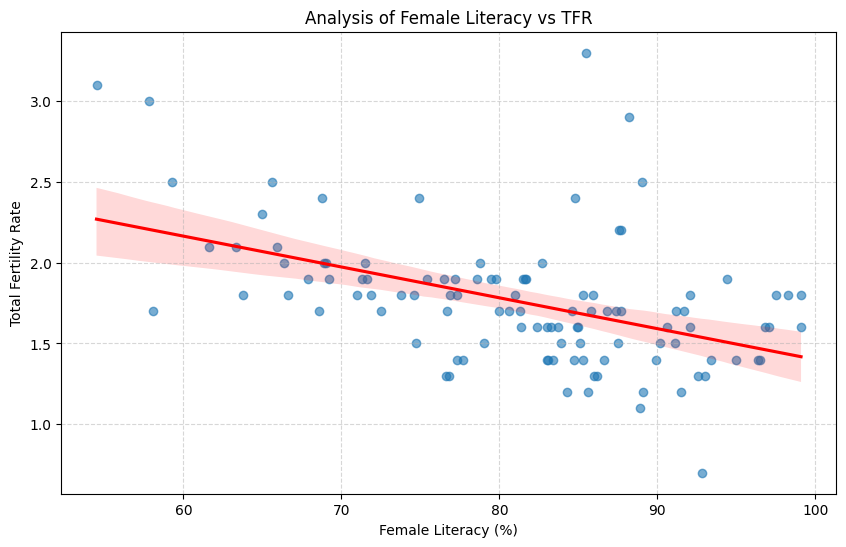

In [30]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x=cols[0], y=cols[1], 
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Analysis of Female Literacy vs TFR')
plt.xlabel('Female Literacy (%)')
plt.ylabel('Total Fertility Rate')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('literacy_vs_tfr.png', dpi=300)
plt.show()

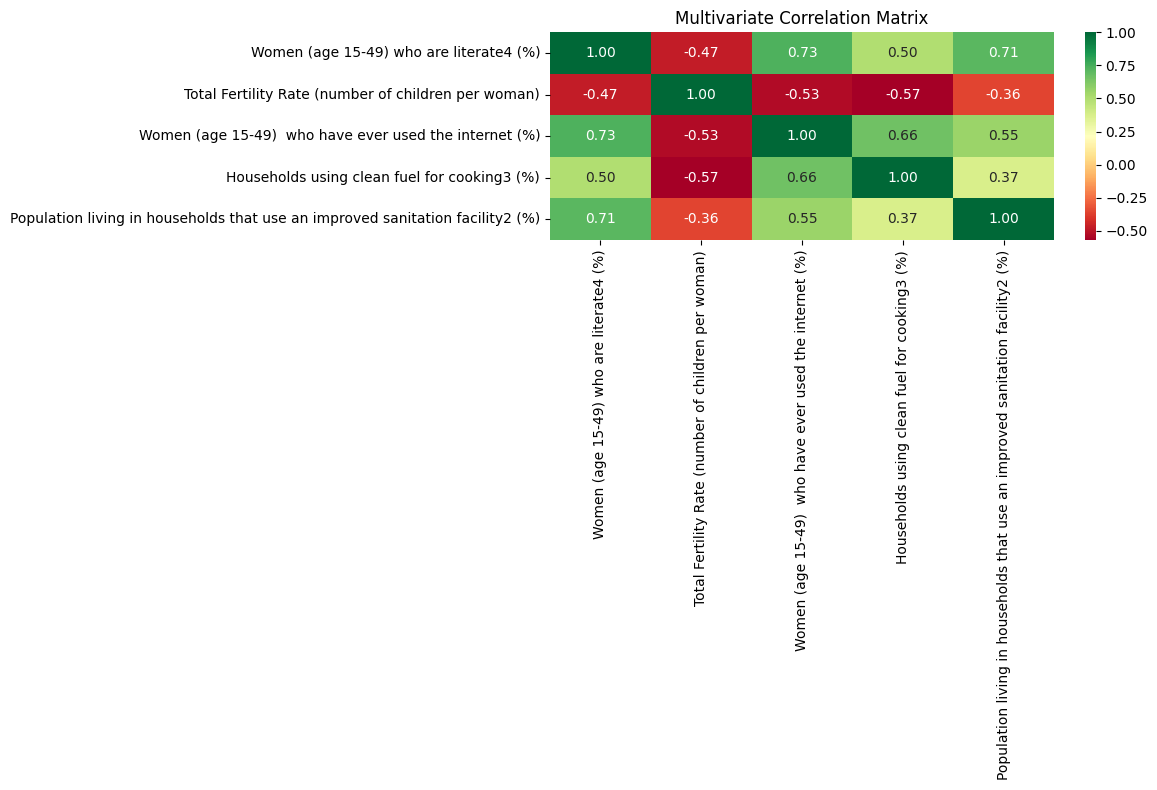

In [31]:
plt.figure(figsize=(12, 8))
correlation_matrix = df[cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Multivariate Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

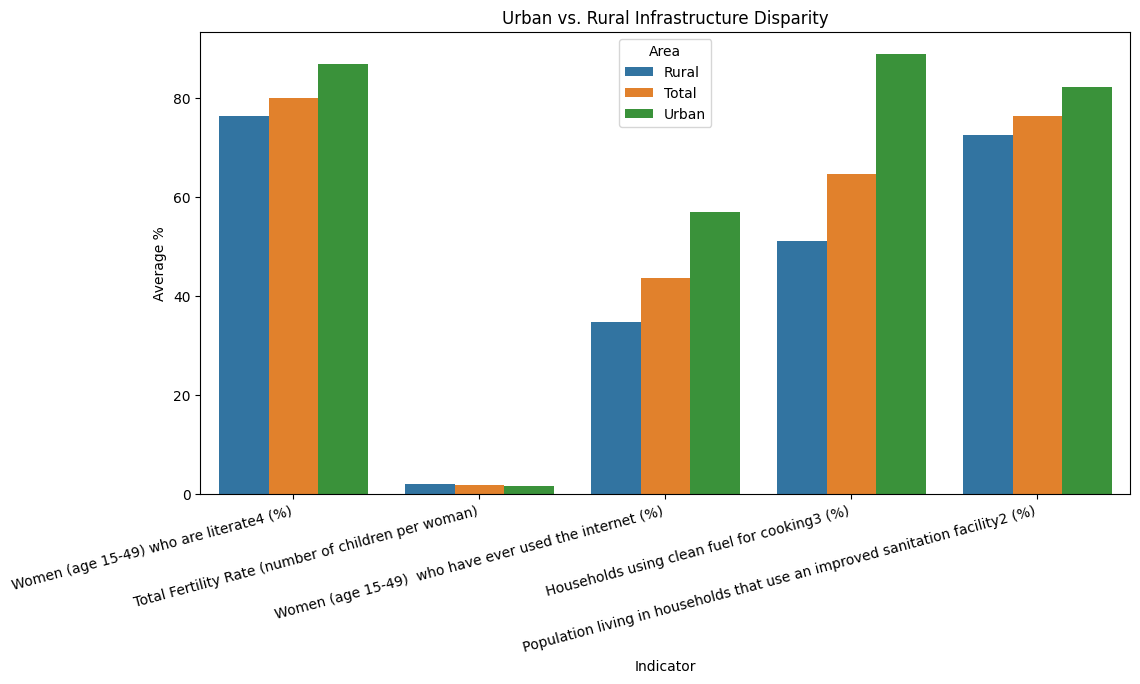

In [32]:
# Grouping data by Area (Urban/Rural)
area_stats = df.groupby('Area')[cols].mean().reset_index()
melted_df = area_stats.melt(id_vars='Area', var_name='Indicator', value_name='Average %')

plt.figure(figsize=(12, 6))
sns.barplot(data=melted_df, x='Indicator', y='Average %', hue='Area')
plt.xticks(rotation=15, ha='right')
plt.title('Urban vs. Rural Infrastructure Disparity')
plt.show()

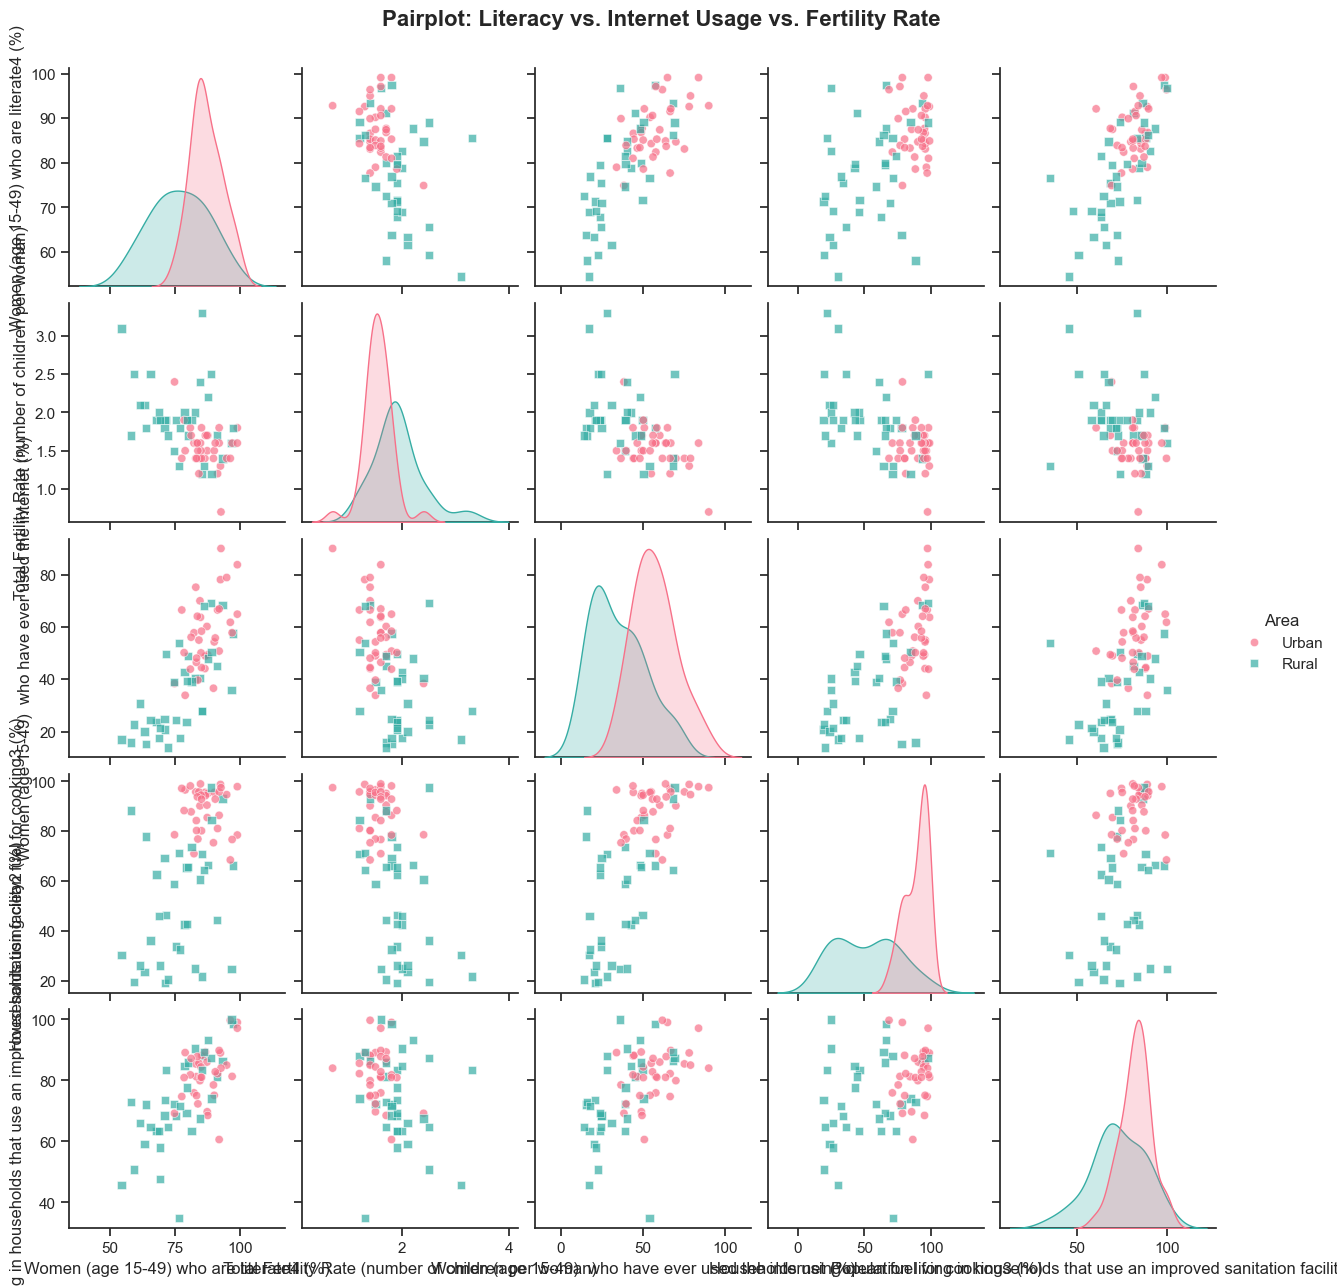

In [34]:
pairplot_df = df[(df['States/UTs'] != 'India') & (df['Area'].isin(['Urban', 'Rural']))].copy()

# 5. Generate the Pairplot
sns.set_theme(style="ticks")

# Create the plot
g = sns.pairplot(
    pairplot_df[cols + ['Area']], 
    hue='Area',               # Colors the points by Urban/Rural
    palette='husl',          # A nice color palette
    diag_kind='kde',         # Smooth density curves on the diagonal
    markers=["o", "s"],      # Different shapes for Urban and Rural
    plot_kws={'alpha': 0.7}  # Transparency for overlapping points
)

# Set a title for the entire grid
g.fig.suptitle('Pairplot: Literacy vs. Internet Usage vs. Fertility Rate', y=1.03, fontsize=16, fontweight='bold')

plt.show()

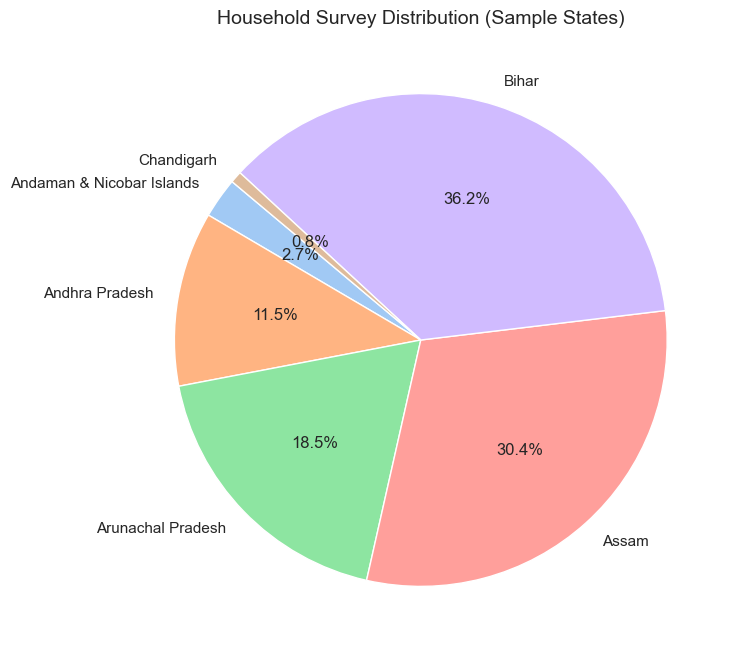

In [36]:
pie_data = df[(df['Area'] == 'Total') & (df['States/UTs'] != 'India')].head(6) 
plt.figure(figsize=(8, 8))
plt.pie(pie_data['Number of Households surveyed'], labels=pie_data['States/UTs'], autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette('pastel'))
plt.title('Household Survey Distribution (Sample States)', fontsize=14)
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2836\432827201.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Area', y='Women (age 15-49) who are literate4 (%)', data=plot_df, palette='Set2')


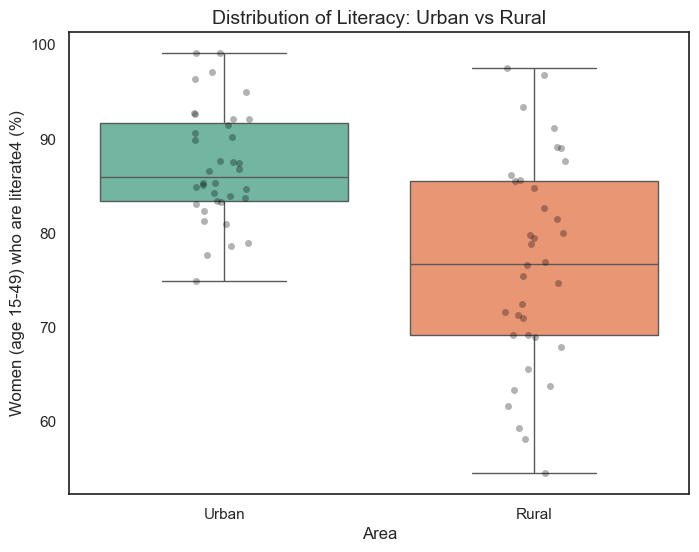

In [37]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Area', y='Women (age 15-49) who are literate4 (%)', data=plot_df, palette='Set2')
sns.stripplot(x='Area', y='Women (age 15-49) who are literate4 (%)', data=plot_df, color='black', alpha=0.3)
plt.title('Distribution of Literacy: Urban vs Rural', fontsize=14)
plt.show()

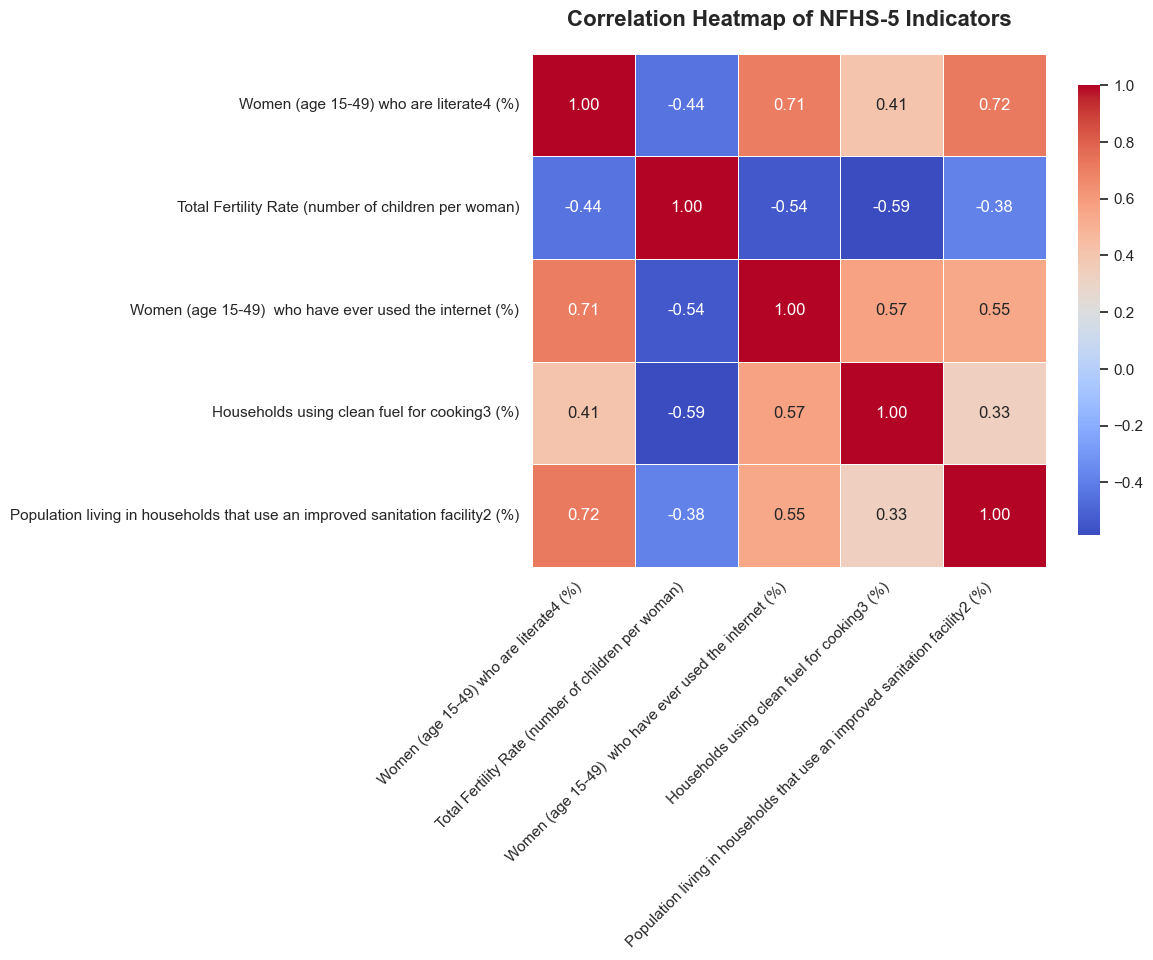

In [38]:
corr_matrix = df[(df['Area'] == 'Total') & (df['States/UTs'] != 'India')][cols].corr()

# 5. Plot the Heatmap
plt.figure(figsize=(12, 10))

# Create the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,          # Shows the numbers in the boxes
    fmt=".2f",           # Formats numbers to 2 decimal places
    cmap='coolwarm',     # Red for positive, Blue for negative correlation
    linewidths=0.5,      # Adds lines between squares
    square=True,         # Makes the cells perfectly square
    cbar_kws={"shrink": .8} # Adjusts the size of the color bar
)

# Set labels and title
plt.title('Correlation Heatmap of NFHS-5 Indicators', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()